In [5]:
import numpy as np
import astropy.wcs as wcs
from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import SkyCoord
import astropy.units as u
from spectral_cube import SpectralCube

from matplotlib import pyplot as plt
import numpy as np  # Ensure numpy is imported
import matplotlib
from collections import OrderedDict

results = OrderedDict()

/software/projects/mwaeor/dev/spectralcube_asep/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [72]:
# base, suff, nch="/scratch/mwaeor/dev/gama9/1271676902/1271676902_spec", "dirty", 384
# base, suff, nch="/scratch/mwaeor/dev/gama9/1271676902/outlierVirA", "XX-dirty", 64
# base, suff, nch, gpstime="/scratch/mwaeor/dev/gama9/1271676902/1271676902_allsky", "XX-dirty", 64, 1271676902
# base, suff, nch, gpstime="/scratch/mwaeor/dev/gama9/1271676902/iono_allsky", "XX-dirty", 64, 1271676902
base, suff, nch, gpstime="/scratch/mwaeor/dev/gama9/1271676902/model_allsky", "XX-dirty", 64, 1271676902
base_tail = base.split("/")[-1]
mfs_hdu = fits.open(f"{base}-MFS-{suff}.fits")
im_shape = mfs_hdu[0].data[0][0].shape
im_wcs = wcs.WCS(mfs_hdu[0].header)
print(im_wcs.printwcs())
print(im_wcs.wcs.ctype[1])

WCS Keywords

Number of WCS axes: 4
CTYPE : 'RA---SIN' 'DEC--SIN' 'FREQ' 'STOKES'
CUNIT : 'deg' 'deg' 'Hz' ''
CRVAL : 142.400565821441 -26.7094492231958 215640000.0 -5.0
CRPIX : 1025.0 1025.0 1.0 1.0
PC1_1 PC1_2 PC1_3 PC1_4  : 1.0 0.0 0.0 0.0
PC2_1 PC2_2 PC2_3 PC2_4  : 0.0 1.0 0.0 0.0
PC3_1 PC3_2 PC3_3 PC3_4  : 0.0 0.0 1.0 0.0
PC4_1 PC4_2 PC4_3 PC4_4  : 0.0 0.0 0.0 1.0
CDELT : -0.058594 0.058594 30720000.0 1.0
NAXIS : 2048  2048  1  1
None
DEC--SIN


In [73]:
# time of observation
t = Time(gpstime, format='gps')
print(t.iso)

2020-04-23 11:35:21.000


In [ ]:
# TODO: Use image WCS to create vals for cube WCS
mfs_hdu = fits.open(f"{base}-MFS-{suff}.fits")
im_shape = mfs_hdu[0].data[0][0].shape
im_wcs = wcs.WCS(mfs_hdu[0].header)

w = wcs.WCS(naxis=3)
wcs_dict = {
    'CTYPE1': 'RA---SIN',
    'CUNIT1': 'deg',
    "CDELT1": im_wcs.wcs.cdelt[0],
    "NAXIS1": im_shape[0],
    "CRPIX1": im_wcs.wcs.crpix[0],
    "CRVAL1": im_wcs.wcs.crval[0],
    'CTYPE2': 'DEC--SIN',
    'CUNIT2': 'deg',
    "CDELT2": im_wcs.wcs.cdelt[1],
    "NAXIS2": im_shape[1],
    "CRPIX2": im_wcs.wcs.crpix[1],
    "CRVAL2": im_wcs.wcs.crval[1],
    'CTYPE3': 'FREQ',
    'CUNIT3': 'Hz',
    "CDELT3": im_wcs.wcs.cdelt[2]/nch,
    "NAXIS3": nch,
    "CRPIX3": 1,
    "CRVAL3": im_wcs.wcs.crval[2]-(im_wcs.wcs.cdelt[2]/2),
}
input_wcs = wcs.WCS(wcs_dict)
print(input_wcs.printwcs())

WCS Keywords

Number of WCS axes: 3
CTYPE : 'RA---SIN' 'DEC--SIN' 'FREQ'
CUNIT : 'deg' 'deg' 'Hz'
CRVAL : 142.400565821441 -26.7094492231958 200280000.0
CRPIX : 1025.0 1025.0 1.0
PC1_1 PC1_2 PC1_3  : 1.0 0.0 0.0
PC2_1 PC2_2 PC2_3  : 0.0 1.0 0.0
PC3_1 PC3_2 PC3_3  : 0.0 0.0 1.0
CDELT : -0.058594 0.058594 30720000.0
NAXIS : 2048  2048  64
None


In [75]:
mfs_hdu = fits.open(f"{base}-0000-{suff}.fits")
im_shape = mfs_hdu[0].data[0][0].shape
im_cube = np.zeros((nch, im_shape[0], im_shape[1]))
wcs_cube = []
mfs_hdu.close()

for i in range(im_cube.shape[0] - 1):
    hdu = fits.open(f"{base}-{i:04d}-{suff}.fits")
    imdata = hdu[0].data[0][0]
    im_wcs = hdu[0].header
    im_cube[i, :, :] = imdata
    wcs_cube.append(im_wcs)
    hdu.close()

hdu_out = fits.PrimaryHDU(data=im_cube,header=input_wcs.to_header())
hdu_out.writeto(f"{base}-{suff}-cube.fits", overwrite=True)


In [76]:
cube_data = fits.open(f"{base}-{suff}-cube.fits")
cube = SpectralCube.read(cube_data)
cube_data.close()

In [77]:
print(cube)

SpectralCube with shape=(64, 2048, 2048):
 n_x:   2048  type_x: RA---SIN  unit_x: deg    range:          nan deg:         nan deg
 n_y:   2048  type_y: DEC--SIN  unit_y: deg    range:          nan deg:         nan deg
 n_s:     64  type_s: FREQ      unit_s: Hz     range: 200280000.000 Hz:2135640000.000 Hz


GLEAM J084125-754033: World (RA=130.357, Dec=-75.676) -> pixel (1074,284)
GLEAM J090225-051639: World (RA=135.606, Dec=-5.278) -> pixel (1139,1378)
GLEAM J085328-034104: World (RA=133.367, Dec=-3.685) -> pixel (1177,1401)
GLEAM J094746+072509: World (RA=146.944, Dec=7.419) -> pixel (947,1571)
GLEAM J123049+122321: World (RA=187.706, Dec=12.389) -> pixel (345,1513)
GLEAM J091804-120641: World (RA=139.518, Dec=-12.112) -> pixel (1072,1270)


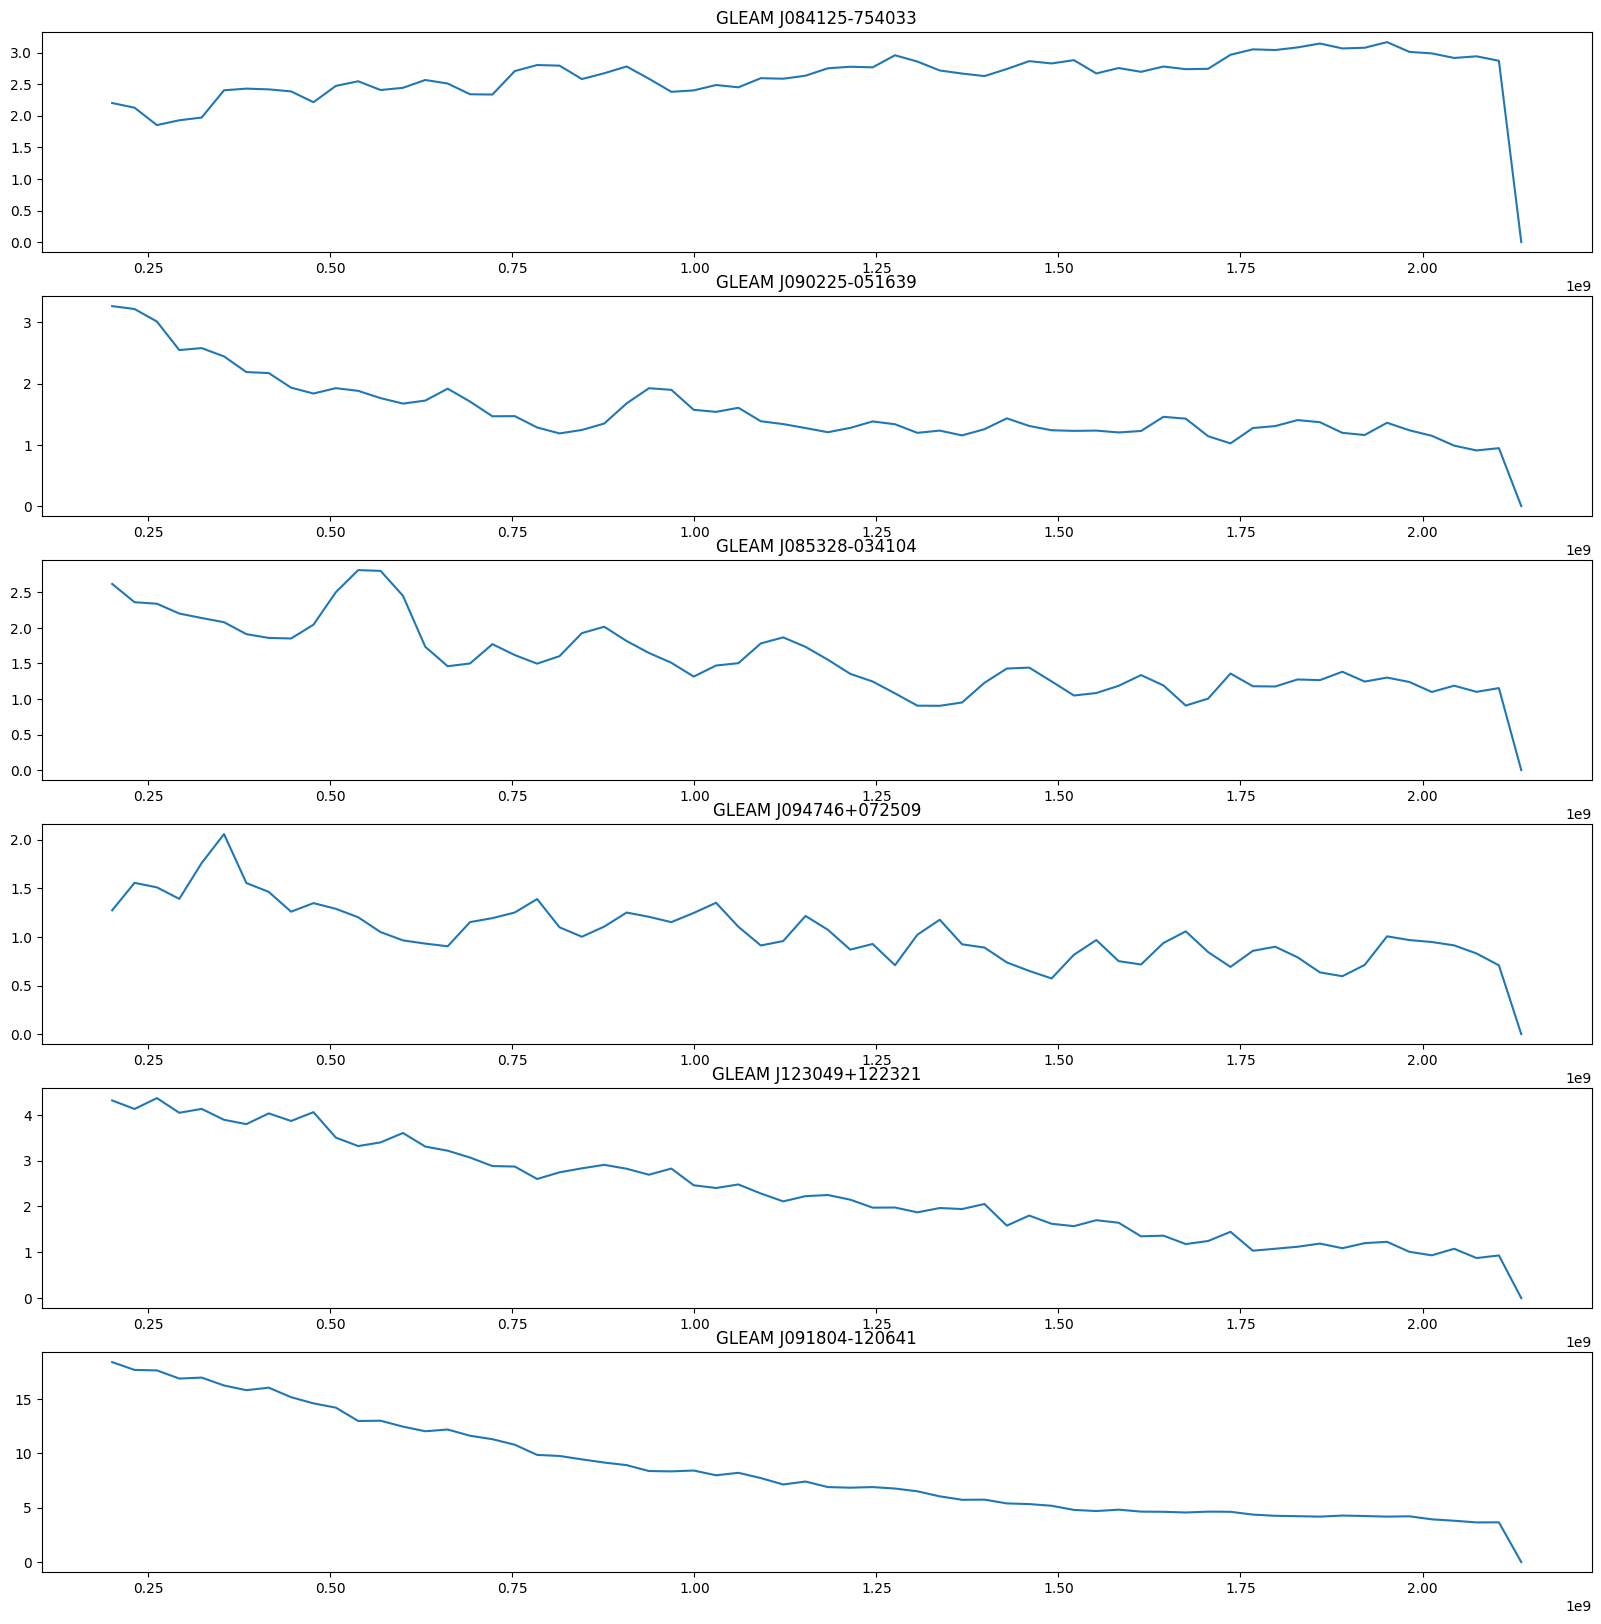

In [ ]:
# One axis per source, plot the spectra, but handle failures gracefully.
# GLEAM J084125-754033
# GLEAM J090225-051639
# GLEAM J085328-034104
# GLEAM J094746+072509
# GLEAM J123049+122321

sources = [
    ("GLEAM J084125-754033", (130.357, -75.676)),
    ("GLEAM J090225-051639", (135.606, -5.278)),
    ("GLEAM J085328-034104", (133.367, -3.685)),
    ("GLEAM J094746+072509", (146.944, 7.419)),
    ("GLEAM J123049+122321", (187.706, 12.389)),
    # WCS: (9:18:04, -12:06:41); Image: (1072, 1270);")
    ("GLEAM J091804-120641", (139.518, -12.112)),
]

fig, axs = plt.subplots(len(sources), 1, figsize=(20, 20))


for ax, (name, pos) in zip(axs, sources):
    ra, dec = pos
    # Defensive: supply obstime=t only if variable t is defined, else fallback to no obstime
    try:
        skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs', obstime=t)
    except Exception:
        skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')

    try:
        # Use central spectral channel for coordinate conversion.
        freq = cube.spectral_axis[len(cube.spectral_axis) // 2]
        # The below expects (spec, dec, ra) ordering.
        pix = cube.wcs.world_to_array_index_values(ra, dec, freq)
        # pix can contain invalid values (e.g., nan, -9223372036854775808) if outside image.
        spec_i, iy, ix = pix

        if (
            any([
                ix is None, iy is None,
                np.isnan(ix), np.isnan(iy),
                ix == -9223372036854775808, iy == -9223372036854775808,
                not np.isfinite(ix), not np.isfinite(iy)
            ])
            or int(np.round(ix)) < 0 or int(np.round(iy)) < 0
            or int(np.round(ix)) >= cube.shape[2] or int(np.round(iy)) >= cube.shape[1]
        ):
            print(f"{name}: World (RA={ra}, Dec={dec}) -> pixel (invalid), skipping")
            ax.set_title(f"{name} (no data)")
            ax.text(0.5, 0.5, "Invalid: Out of bounds", horizontalalignment='center',
                    verticalalignment='center', fontsize=14, transform=ax.transAxes)
            continue

        print(f"{name}: World (RA={ra}, Dec={dec}) -> pixel ({int(np.round(ix))},{int(np.round(iy))})")
    except Exception as e:
        print(f"Failed to convert world to pixel for {name}: {e}")
        ax.set_title(f"{name} (coord error)")
        ax.text(0.5, 0.5, "Coord transform failed", horizontalalignment='center',
                verticalalignment='center', fontsize=14, transform=ax.transAxes)
        continue

    # Round and clip indices to valid integer range (added safety)
    ix_val = int(np.clip(np.round(ix), 0, cube.shape[2] - 1))
    iy_val = int(np.clip(np.round(iy), 0, cube.shape[1] - 1))

    # spectra extraction is over spectral axis at position [iy, ix]
    try:
        spectra = cube[:, iy_val, ix_val]
        results[(base_tail, name, suff)] = spectra
        ax.plot(spectra.spectral_axis.value, spectra.value)
        ax.set_title(name)
    except Exception as e:
        print(f"Failed to extract/plot spectra for {name}: {e}")
        ax.set_title(f"{name} (no extractable spectrum)")
        ax.text(0.5, 0.5, "Spectrum extraction failed", horizontalalignment='center',
                verticalalignment='center', fontsize=14, transform=ax.transAxes)



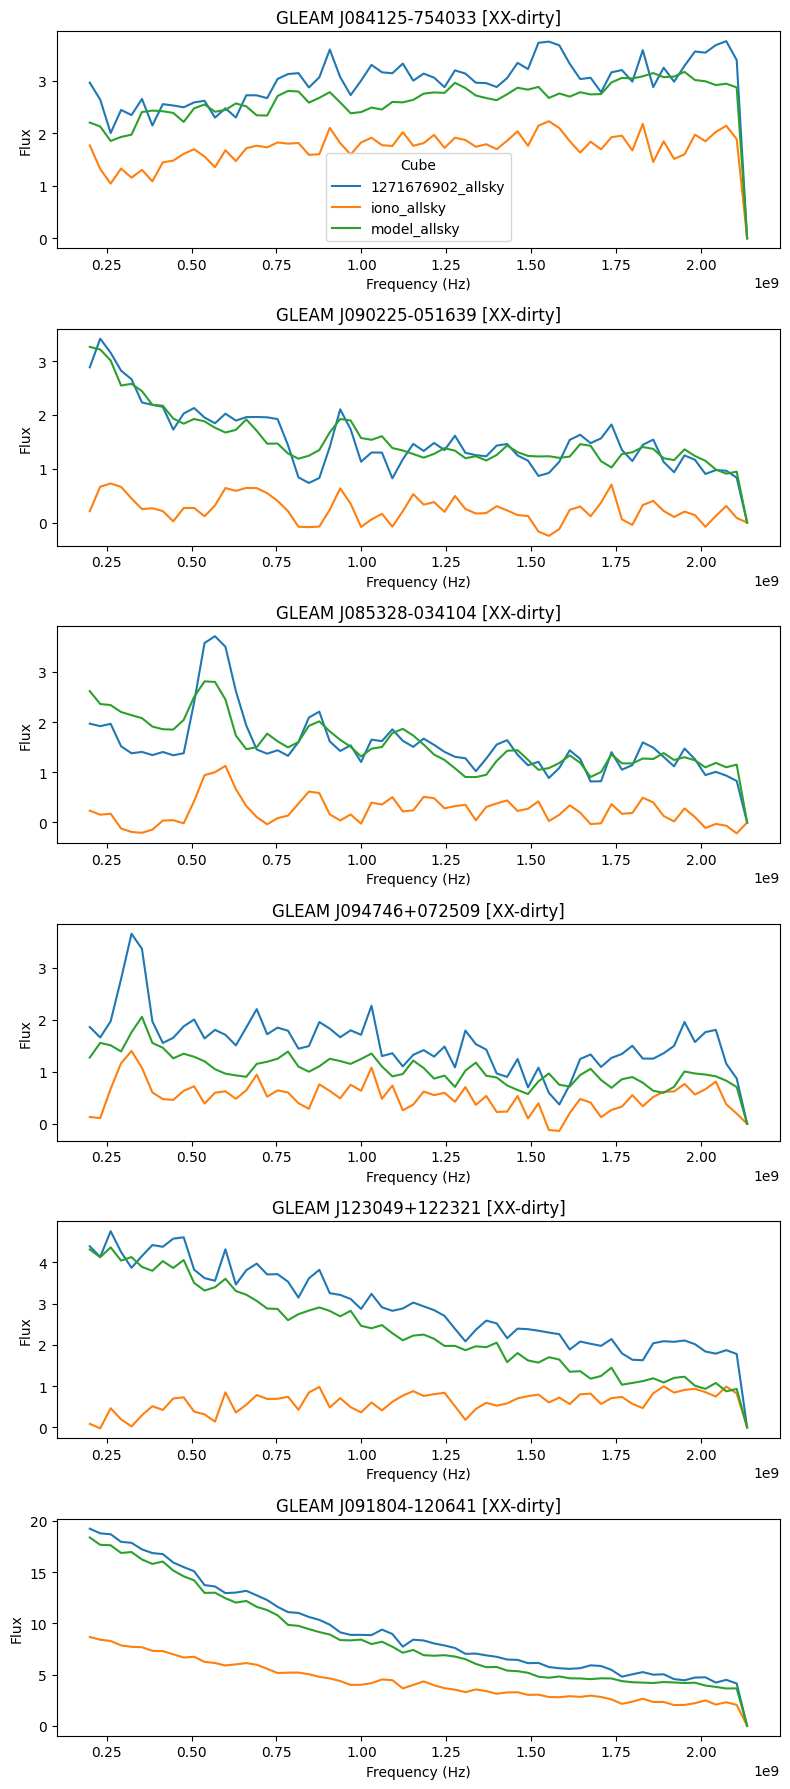

In [81]:
# Plot spectra: one axis per source, all base_tail variants (i.e. cubes) per source as different colors
from collections import defaultdict, OrderedDict
import matplotlib.pyplot as plt

# Group spectra by (name, suff), i.e. by source, collect spectra with different base_tails
grouped = defaultdict(list)
base_tail_order = OrderedDict()  # To keep base_tail order for consistent color assignment
for (base_tail, name, suff), spectrum in results.items():
    if base_tail not in base_tail_order:
        base_tail_order[base_tail] = None
    grouped[(name, suff)].append((base_tail, spectrum))

# Assign a color to each base_tail, globally, so that colors match between axes
color_names = plt.rcParams['axes.prop_cycle'].by_key().get('color', ['C0','C1','C2','C3','C4','C5','C6'])
base_tail_list = list(base_tail_order.keys())
color_dict = {bt: color_names[i % len(color_names)] for i, bt in enumerate(base_tail_list)}

nsrc = len(grouped)
fig, axes = plt.subplots(nsrc, 1, figsize=(8, 3 * nsrc), squeeze=False)
axes = axes[:,0]  # Flatten in case nsrc == 1

for i, ((name, suff), spectra_list) in enumerate(grouped.items()):
    ax = axes[i]
    for base_tail, spectrum in spectra_list:
        color = color_dict[base_tail]
        ax.plot(spectrum.spectral_axis.value, spectrum.value, label=base_tail, color=color)
    # Title and axis labels
    ax.set_title(f"{name} [{suff}]")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Flux")
    if i == 0:
        # Only add legend on the first axis for clarity
        handles, labels = [], []
        for bt in base_tail_list:
            handles.append(plt.Line2D([], [], color=color_dict[bt], label=bt))
            labels.append(bt)
        ax.legend(handles=handles, title="Cube", loc='best')
plt.tight_layout()
plt.show()

Filename: /scratch/mwaeor/dev/gama9/1271676902/model.cross-HydA.img1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      30   (5, 5, 4)   float32   
(4, 5, 5)


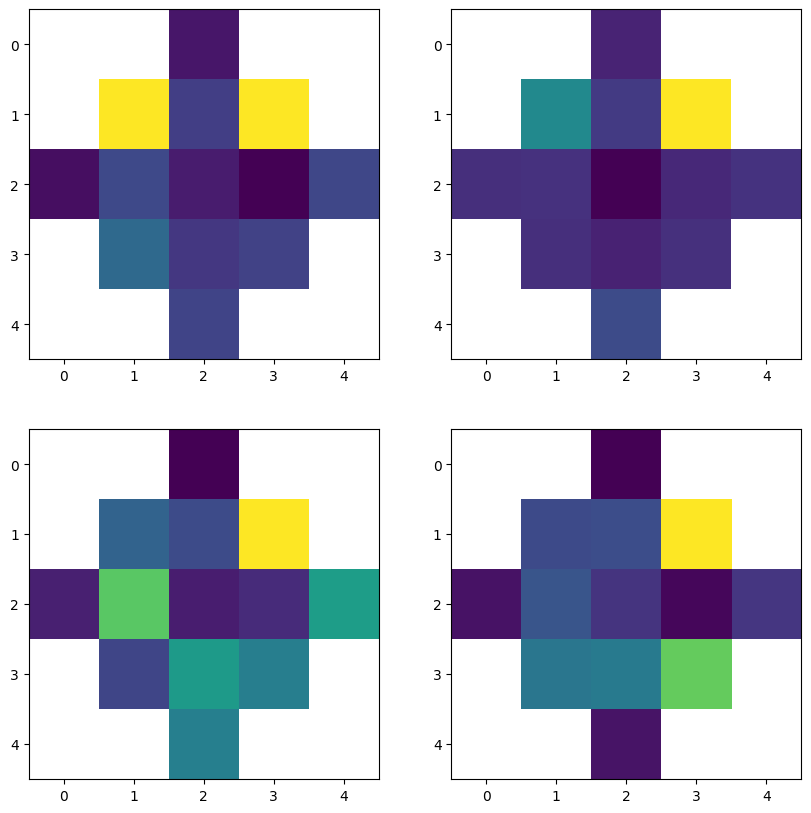

In [ ]:
from astropy.io import fits
with fits.open("/scratch/mwaeor/dev/gama9/1271676902/model.cross-HydA.img1.fits") as hdul:
    hdul.info()
    print(hdul[0].data.shape)
    # fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    # ax.plot(hdul[0].data[0, :, 0, 0], label="real")
    # ax.plot(hdul[0].data[1, :, 0, 0], label="imag")
    # ax.legend()
    # plt.show()
    fig, ax = plt.subplots(2, 2, figsize=(10, 10))
    ax[0, 0].imshow(hdul[0].data[0, :, :])
    ax[0, 1].imshow(hdul[0].data[1, :, :])
    ax[1, 0].imshow(hdul[0].data[2, :, :])
    ax[1, 1].imshow(hdul[0].data[3, :, :])
    plt.show()

